# [**E-Commerce - Kaggle**](https://www.kaggle.com/datasets/meruvakodandasuraj/e-commerce-customer-behavior-and-sales-20202026)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

df_raw = pd.read_csv('Data/customer_behave/customers.csv')
df_raw

,customer_id,country,age,gender,membership_tier,registration_date,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
0,C00001,United States,40,Male,Free,2019-01-17,4,286.63,63.78,49,Food & Grocery,Mobile,Debit Card,Social Media,1,4.5,0,12,0,0
1,C00002,United States,20,Female,Free,2026-03-04,11,1245.18,107.32,126,Toys & Games,Mobile,Debit Card,Organic Search,2,2.6,1,1,0,0
2,C00003,United States,43,Female,Gold,2026-02-08,4,195.37,42.74,0,Home & Kitchen,Mobile,PayPal,Referral,0,4.8,0,0,1,0
3,C00004,United States,41,Male,Free,2025-03-19,6,99.45,15.61,6,Electronics,Desktop,PayPal,Organic Search,2,4.2,0,8,1,0
4,C00005,France,37,Other,Platinum,2024-09-10,36,2593.21,79.09,161,Clothing & Apparel,Tablet,Debit Card,Social Media,9,4.0,4,5,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,C07996,United States,36,Male,Gold,2025-07-09,13,1953.76,175.38,40,Jewelry & Accessories,Tablet,Debit Card,Social Media,1,4.4,1,14,1,1
7996,C07997,India,42,Male,Free,2025-06-28,31,6772.20,251.76,53,Electronics,Mobile,Credit Card,Paid Ad,12,4.6,4,1,0,0
7997,C07998,India,34,Male,Platinum,2026-02-01,46,2430.09,58.01,18,Home & Kitchen,Desktop,Cryptocurrency,Organic Search,9,4.2,6,0,1,0
7998,C07999,Japan,44,Female,Free,2026-01-15,35,5552.56,147.22,50,Food & Grocery,Mobile,Credit Card,Paid Ad,10,4.1,1,2,0,0


In [2]:
df_raw.isnull().sum()

customer_id                 0
country                     0
age                         0
gender                      0
membership_tier             0
registration_date           0
total_orders                0
total_spend_usd             0
avg_order_value_usd         0
days_since_last_purchase    0
preferred_category          0
preferred_device            0
preferred_payment_method    0
acquisition_channel         0
reviews_given               0
avg_review_score            0
returns_made                0
wishlist_items              0
newsletter_subscribed       0
churned                     0
dtype: int64

In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               8000 non-null   str    
 1   country                   8000 non-null   str    
 2   age                       8000 non-null   int64  
 3   gender                    8000 non-null   str    
 4   membership_tier           8000 non-null   str    
 5   registration_date         8000 non-null   str    
 6   total_orders              8000 non-null   int64  
 7   total_spend_usd           8000 non-null   float64
 8   avg_order_value_usd       8000 non-null   float64
 9   days_since_last_purchase  8000 non-null   int64  
 10  preferred_category        8000 non-null   str    
 11  preferred_device          8000 non-null   str    
 12  preferred_payment_method  8000 non-null   str    
 13  acquisition_channel       8000 non-null   str    
 14  reviews_given      

In [4]:
df = df_raw.drop(columns= ['customer_id']).copy()

df['registration_date'] = pd.to_datetime(df['registration_date'])

In [5]:
country_mapping = {
    'United States': 'North America', 'Mexico': 'North America', 'Canada': 'North America',
    'France': 'Europe', 'Germany': 'Europe', 'Netherlands': 'Europe', 
    'United Kingdom': 'Europe', 'Poland': 'Europe', 'Spain': 'Europe', 
    'Italy': 'Europe', 'Sweden': 'Europe',
    'South Africa': 'Africa',
    'UAE': 'Middle-East', 'Turkey': 'Middle-East',
    'Singapore': 'Asia', 'India': 'Asia', 'South Korea': 'Asia', 
    'Japan': 'Asia',
    'Australia': 'Australia',
    'Brazil': 'South America'
}

membership_mapping = {
    'Free'  :0, 
    'Silver':1, 
    'Gold'  :2, 
    'Platinum': 3,
}

df['region'] = df['country'].map(country_mapping)
df['membership'] = df['membership_tier'].map(membership_mapping)

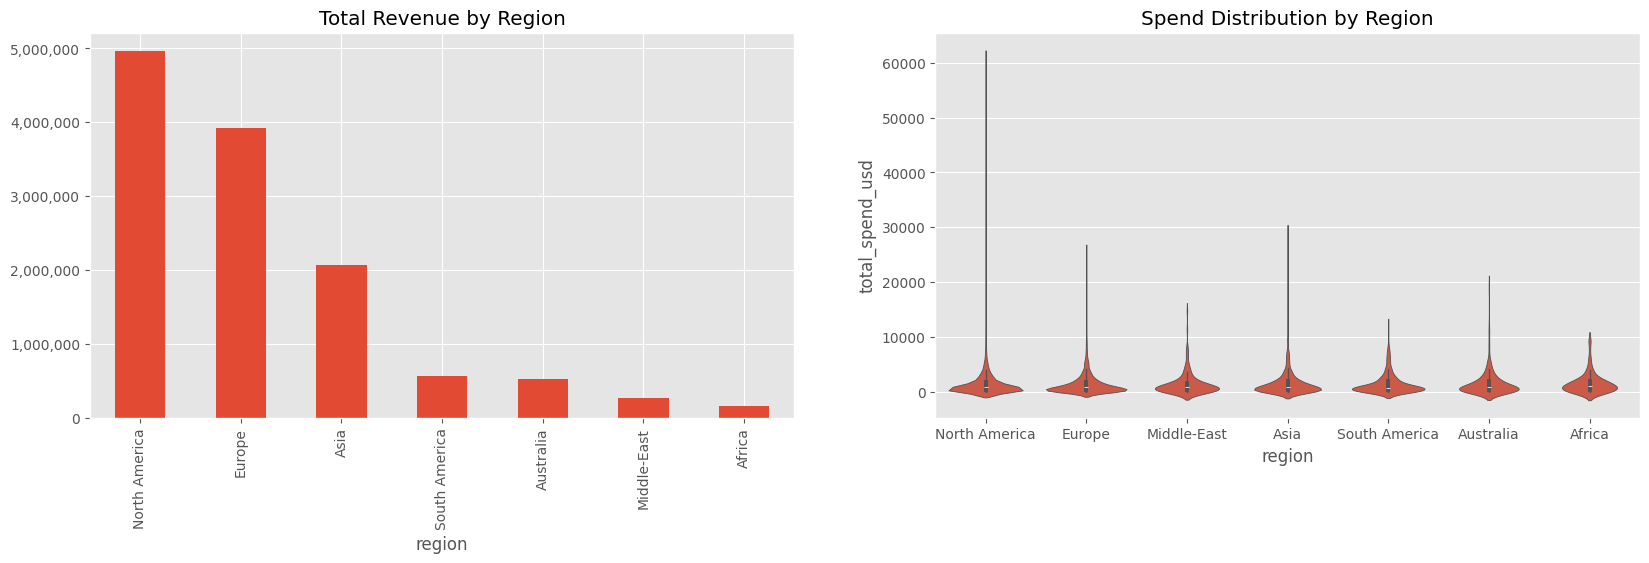

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))

df.groupby('region')['total_spend_usd'].sum().sort_values(ascending=False).plot(kind='bar', ax=ax1)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax1.set_title('Total Revenue by Region')



sns.violinplot(df, x='region', y='total_spend_usd', ax=ax2)
ax2.set_title('Spend Distribution by Region')

plt.show()


Most of our market is in the North America (US, Canada, Mexico), followed by Europe and Asia

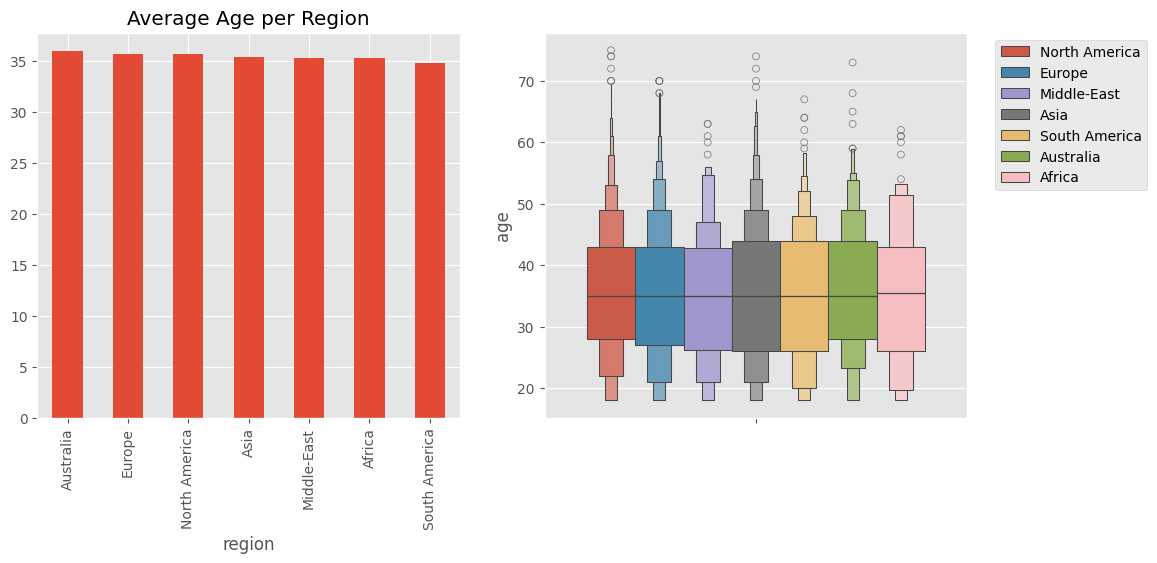

In [7]:
plt.figure(figsize = (12, 5))

plt.subplot(1, 2, 1)
df.groupby('region')['age'].mean().sort_values(ascending= False).plot(kind = 'bar')
plt.title('Average Age per Region')

plt.subplot(1, 2, 2)
sns.boxenplot(df, y = 'age', hue = 'region')
plt.legend(bbox_to_anchor= (1.05, 1))
plt.show()

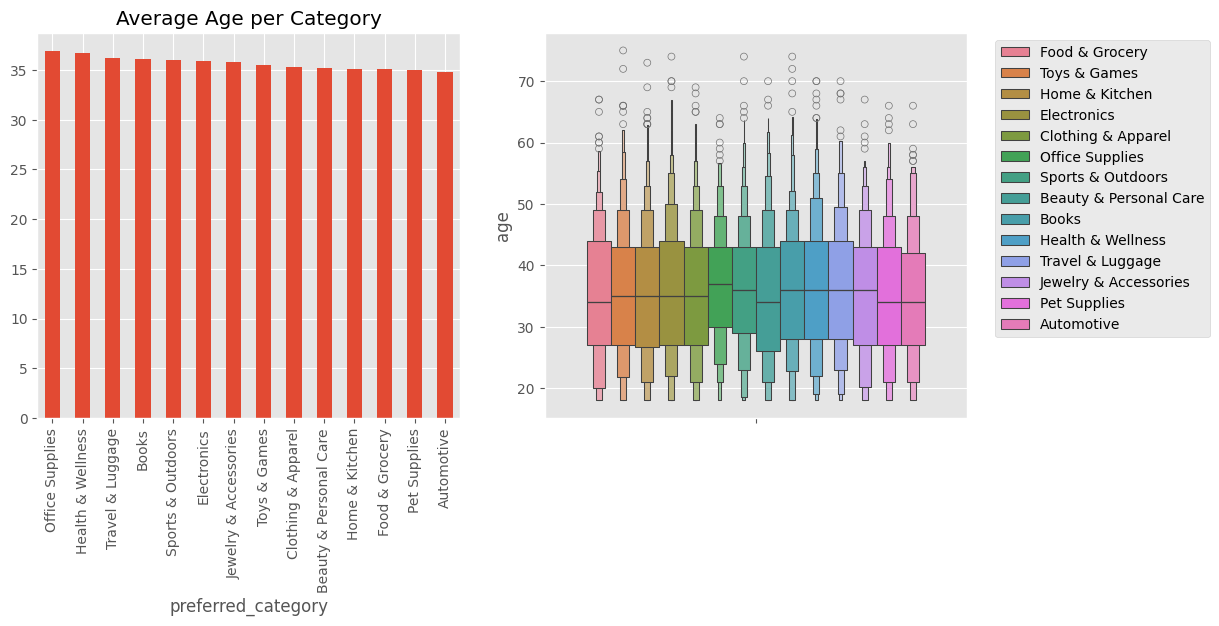

In [8]:
plt.figure(figsize = (12, 5))

plt.subplot(1, 2, 1)
df.groupby('preferred_category')['age'].mean().sort_values(ascending= False).plot(kind = 'bar')
plt.title('Average Age per Category')

plt.subplot(1, 2, 2)
sns.boxenplot(df, y = 'age', hue = 'preferred_category')
plt.legend(bbox_to_anchor= (1.05, 1))
plt.show()

Age range are the same between regions and category

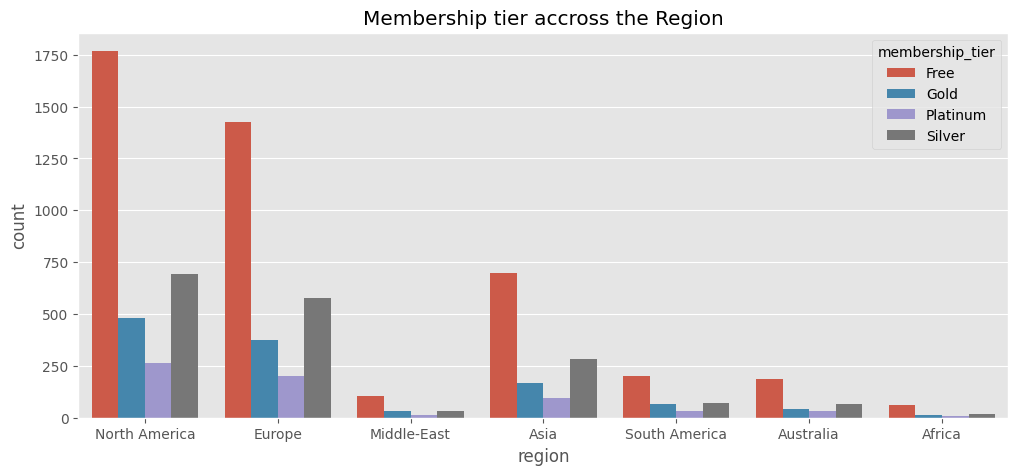

In [9]:
plt.figure(figsize = (12, 5))
sns.countplot(df, x = 'region', hue = 'membership_tier')
plt.title('Membership tier accross the Region')
plt.show()

**Free > Silver > Gold > Platinum**

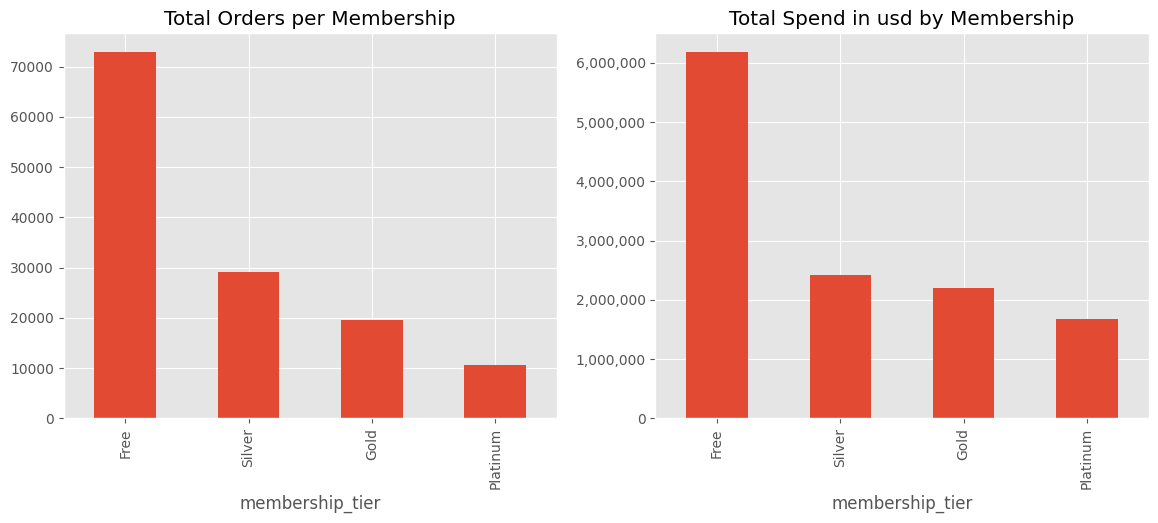

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

df.groupby('membership_tier')['total_orders'].sum().sort_values(ascending=False).plot(kind='bar', ax=ax1)
ax1.set_title('Total Orders per Membership')

df.groupby('membership_tier')['total_spend_usd'].sum().sort_values(ascending=False).plot(kind='bar', ax=ax2)
ax2.set_title('Total Spend in usd by Membership')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.show()


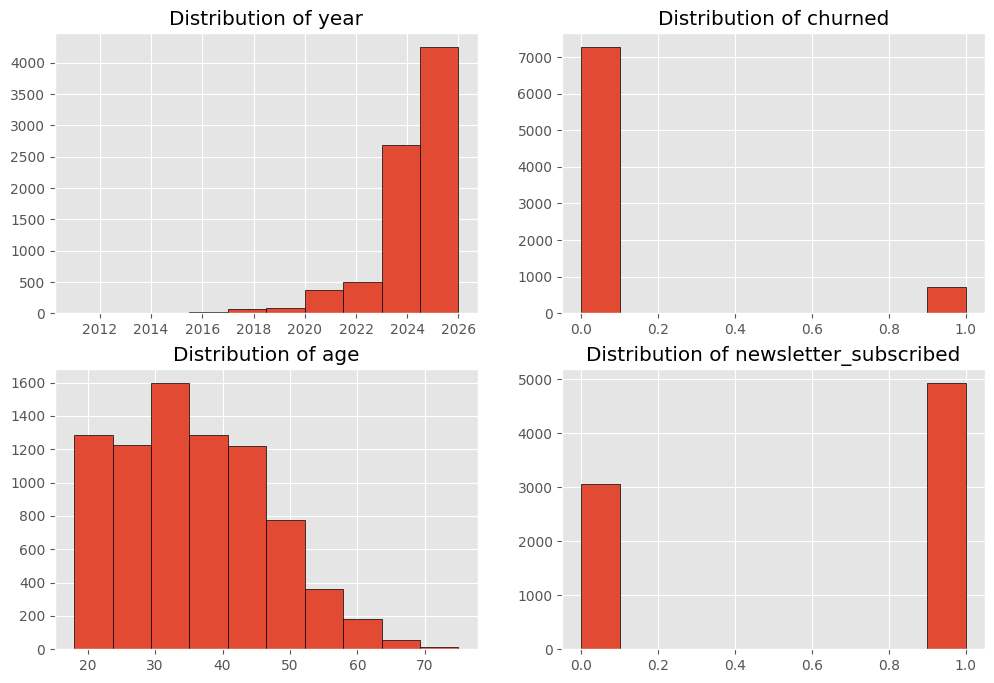

In [11]:
df['year'] = df['registration_date'].dt.year

feature = ['year', 'churned', 'age', 'newsletter_subscribed']
plt.figure(figsize = (12, 8))

for count, item in enumerate(feature):
    plt.subplot(2, 2, count + 1)
    df[item].hist(edgecolor = 'black')
    plt.title(f'Distribution of {item}')
plt.show()

The market has only be booming recently, with a huge number of subscribed recently, and we attract young adults mostly (<= 50)

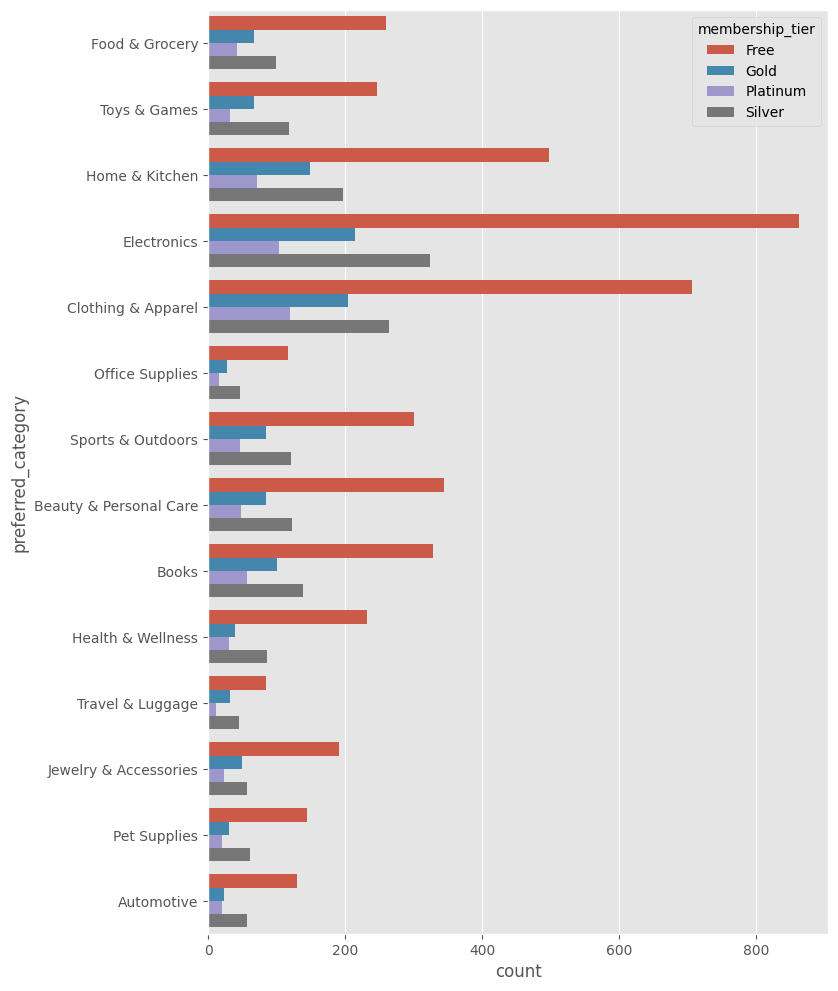

In [12]:
plt.figure(figsize = (8, 12))

sns.countplot(df, y = 'preferred_category', hue = 'membership_tier')
plt.show()

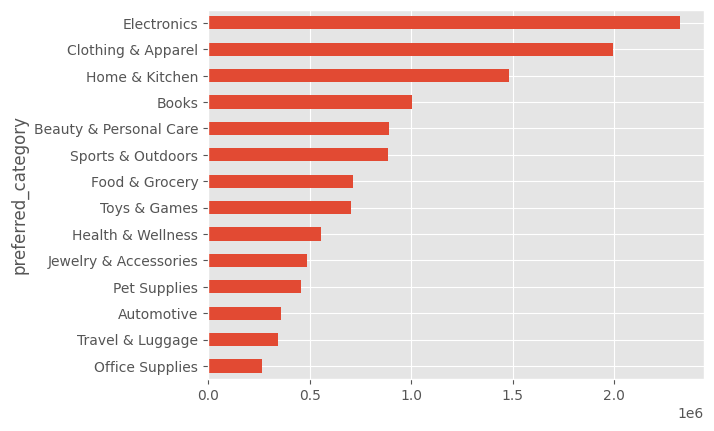

In [13]:
df.groupby('preferred_category')['total_spend_usd'].sum().sort_values().plot(kind = 'barh')
plt.show()

`Electronics` and `Clothing` is the best category we have (both on selling numbers and profit made)

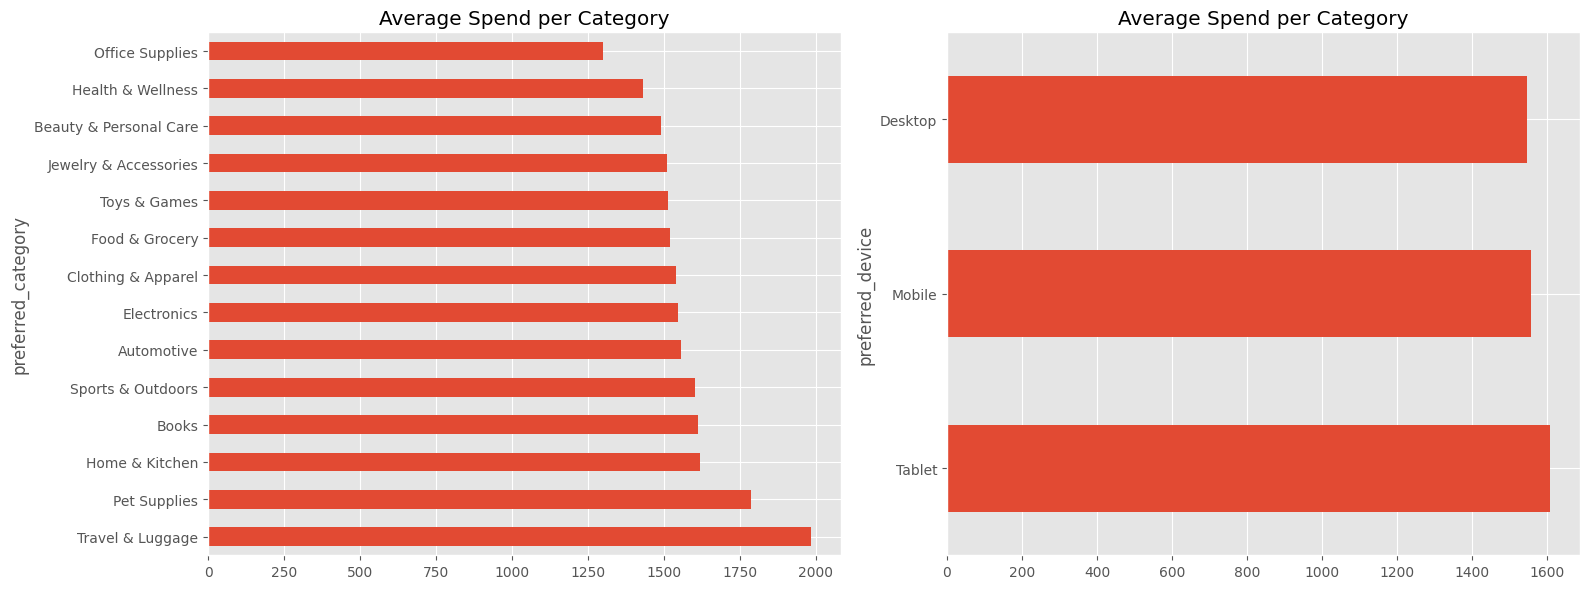

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Total spend per category
df.groupby('preferred_category')['total_spend_usd'].mean().sort_values(ascending=False).plot(kind='barh', ax=ax1)
ax1.set_title('Average Spend per Category')

df.groupby('preferred_device')['total_spend_usd'].mean().sort_values(ascending= False).plot(
    kind = 'barh', ax = ax2
)
ax2.set_title('Average Spend per Category')

plt.tight_layout()
plt.show()


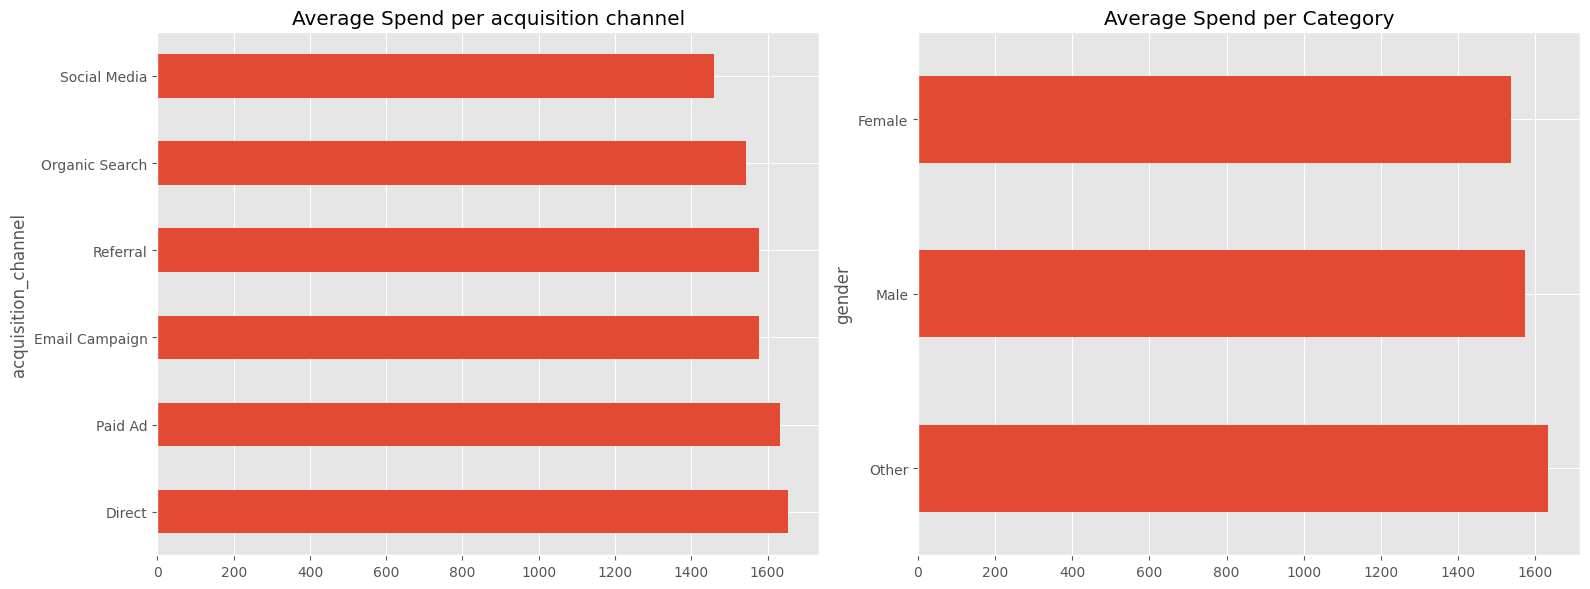

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Total spend per category
df.groupby('acquisition_channel')['total_spend_usd'].mean().sort_values(ascending=False).plot(kind='barh', ax=ax1)
ax1.set_title('Average Spend per acquisition channel')

df.groupby('gender')['total_spend_usd'].mean().sort_values(ascending= False).plot(
    kind = 'barh', ax = ax2
)
ax2.set_title('Average Spend per Category')

plt.tight_layout()
plt.show()


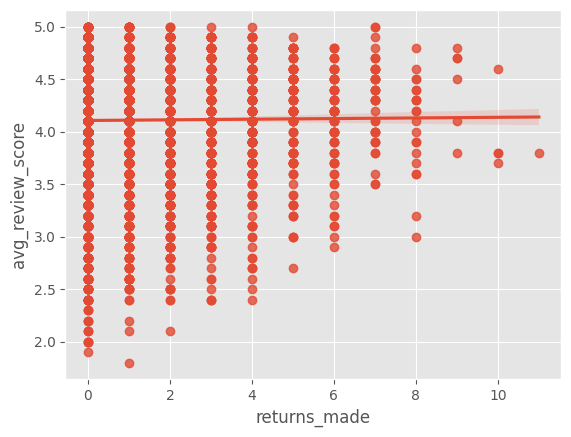

In [16]:
sns.regplot(df, y = 'avg_review_score', x = 'returns_made')
plt.show()

### **EDA Analysis**:


In [17]:
string_col = df.select_dtypes(include=['str', 'object'])

for col in string_col:
    print(f'Feature: {col}')
    print(df[col].unique())
    print('-' * 50)

Feature: country
<ArrowStringArray>
[ 'United States',         'France',            'UAE',         'Canada',
      'Singapore', 'United Kingdom',    'Netherlands',         'Brazil',
         'Mexico',          'Japan',          'India',    'South Korea',
        'Germany',         'Poland',      'Australia',   'South Africa',
         'Turkey',          'Spain',          'Italy',         'Sweden']
Length: 20, dtype: str
--------------------------------------------------
Feature: gender
<ArrowStringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str
--------------------------------------------------
Feature: membership_tier
<ArrowStringArray>
['Free', 'Gold', 'Platinum', 'Silver']
Length: 4, dtype: str
--------------------------------------------------
Feature: preferred_category
<ArrowStringArray>
[        'Food & Grocery',           'Toys & Games',         'Home & Kitchen',
            'Electronics',     'Clothing & Apparel',        'Office Supplies',
      'Sports & Outdoors', '

In [18]:
df['membership']

0       0
1       0
2       2
3       0
4       3
       ..
7995    2
7996    0
7997    3
7998    0
7999    2
Name: membership, Length: 8000, dtype: int64

In [19]:
df_encoded = pd.get_dummies(df, columns= ['region', 'gender',
                                          'preferred_category', 'preferred_device',
                                          'preferred_payment_method', 'acquisition_channel',
                                          ], dtype = int)

df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 56 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   country                                        8000 non-null   str           
 1   age                                            8000 non-null   int64         
 2   membership_tier                                8000 non-null   str           
 3   registration_date                              8000 non-null   datetime64[us]
 4   total_orders                                   8000 non-null   int64         
 5   total_spend_usd                                8000 non-null   float64       
 6   avg_order_value_usd                            8000 non-null   float64       
 7   days_since_last_purchase                       8000 non-null   int64         
 8   reviews_given                                  8000 non-null   int64 

In [20]:
df_encoded.head(5)

,country,age,membership_tier,registration_date,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,reviews_given,avg_review_score,...,preferred_payment_method_Cryptocurrency,preferred_payment_method_Debit Card,preferred_payment_method_PayPal,preferred_payment_method_UPI / Digital Wallet,acquisition_channel_Direct,acquisition_channel_Email Campaign,acquisition_channel_Organic Search,acquisition_channel_Paid Ad,acquisition_channel_Referral,acquisition_channel_Social Media
0,United States,40,Free,2019-01-17,4,286.63,63.78,49,1,4.5,...,0,1,0,0,0,0,0,0,0,1
1,United States,20,Free,2026-03-04,11,1245.18,107.32,126,2,2.6,...,0,1,0,0,0,0,1,0,0,0
2,United States,43,Gold,2026-02-08,4,195.37,42.74,0,0,4.8,...,0,0,1,0,0,0,0,0,1,0
3,United States,41,Free,2025-03-19,6,99.45,15.61,6,2,4.2,...,0,0,1,0,0,0,1,0,0,0
4,France,37,Platinum,2024-09-10,36,2593.21,79.09,161,9,4.0,...,0,1,0,0,0,0,0,0,0,1


In [21]:
df_encoded.columns

Index(['country', 'age', 'membership_tier', 'registration_date',
       'total_orders', 'total_spend_usd', 'avg_order_value_usd',
       'days_since_last_purchase', 'reviews_given', 'avg_review_score',
       'returns_made', 'wishlist_items', 'newsletter_subscribed', 'churned',
       'membership', 'year', 'region_Africa', 'region_Asia',
       'region_Australia', 'region_Europe', 'region_Middle-East',
       'region_North America', 'region_South America', 'gender_Female',
       'gender_Male', 'gender_Other', 'preferred_category_Automotive',
       'preferred_category_Beauty & Personal Care', 'preferred_category_Books',
       'preferred_category_Clothing & Apparel',
       'preferred_category_Electronics', 'preferred_category_Food & Grocery',
       'preferred_category_Health & Wellness',
       'preferred_category_Home & Kitchen',
       'preferred_category_Jewelry & Accessories',
       'preferred_category_Office Supplies', 'preferred_category_Pet Supplies',
       'preferred_categ

In [22]:
from sklearn.preprocessing import StandardScaler

df_scaled = df_encoded.drop(columns=['country', 'registration_date', 'churned', 'membership_tier']).copy()


In [23]:
scaler = StandardScaler()

df_scaled = pd.DataFrame(scaler.fit_transform(df_scaled), columns=df_scaled.columns)


12


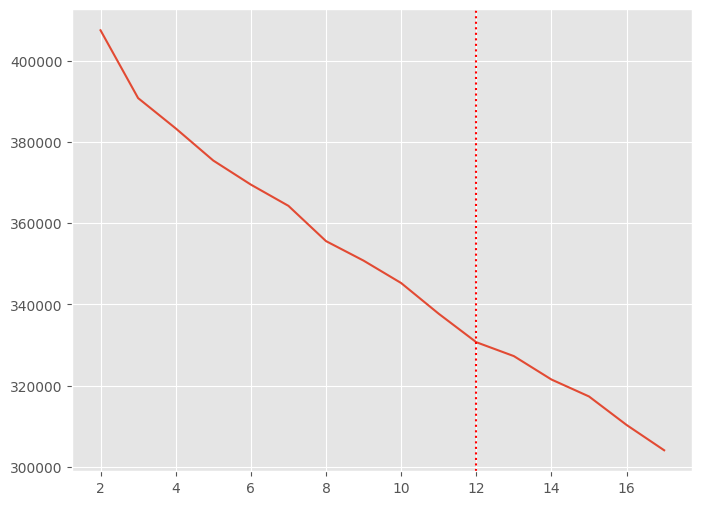

In [24]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

inertias = []

k_range = range(2, 18)

for k in k_range:
    model = KMeans(n_clusters= k, random_state= 8)
    model.fit(df_scaled)
    inertias.append(model.inertia_)

kl = KneeLocator(k_range, inertias, curve= 'convex',
                 direction= 'decreasing')

optimal_k = kl.elbow

print(optimal_k)

plt.figure(figsize = (8, 6))
plt.plot(k_range, inertias)
plt.axvline(optimal_k, color = 'red', linestyle = ':',
            label = f'Optimal k: {optimal_k}')

plt.show()

10


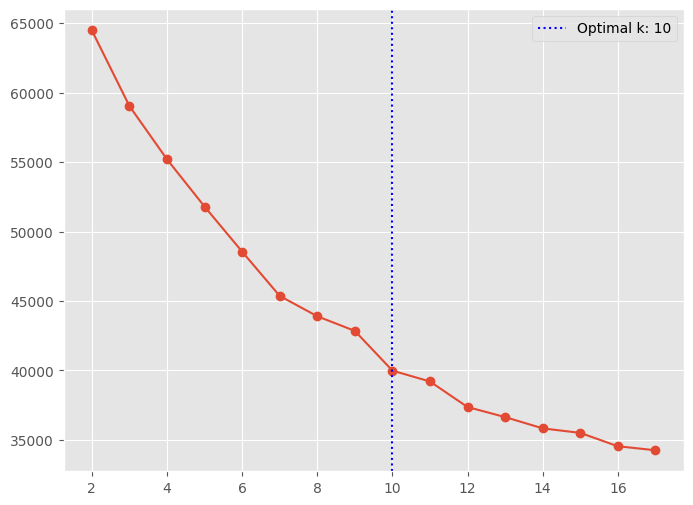

In [25]:
numeric_cols = ['age', 'total_orders', 'total_spend_usd', 'avg_order_value_usd',
                'days_since_last_purchase', 'reviews_given', 'avg_review_score',
                'returns_made', 'wishlist_items', 'membership']

df_numeric = df_scaled[numeric_cols].copy()

inertias = []

k_range = range(2, 18)

for k in k_range:
    model = KMeans(n_clusters= k, random_state= 8)
    model.fit(df_numeric)
    inertias.append(model.inertia_)

kl = KneeLocator(k_range, inertias, curve= 'convex',
                 direction= 'decreasing')

optimal_k = kl.elbow

print(optimal_k)

plt.figure(figsize = (8, 6))
plt.plot(k_range, inertias, marker = 'o')
plt.axvline(optimal_k, color = 'blue', linestyle = ':',
            label = f'Optimal k: {optimal_k}')

plt.legend()
plt.show()

In [26]:
model = KMeans(n_clusters=10, random_state=8)
df['cluster'] = model.fit_predict(df_numeric)

df.groupby('cluster')[numeric_cols].mean()


,age,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,reviews_given,avg_review_score,returns_made,wishlist_items,membership
cluster,,,,,,,,,,
0,36.657313,10.288265,752.510051,76.495553,45.360544,1.664116,3.386905,0.335034,3.288265,0.372449
1,36.235772,53.785908,3755.565908,70.544228,63.596206,13.569106,4.141734,4.813008,3.842818,0.588076
2,34.978159,12.305772,920.251560,76.397551,49.585023,2.268331,4.162090,0.514821,15.826833,0.566303
3,35.881897,10.499516,992.271481,96.966031,45.026137,1.785092,4.149468,0.370765,3.743466,2.398838
4,35.736842,44.877193,17412.700877,414.379649,52.035088,8.438596,4.087719,3.210526,3.701754,1.473684
5,35.522613,10.248744,2966.595000,302.313668,59.469849,1.741206,4.129397,0.334171,4.291457,1.153266
6,34.738292,36.123967,6355.349477,183.275399,49.129477,7.294766,4.122590,2.159780,4.294766,1.330579
7,35.679340,8.590930,607.346761,73.405428,43.022904,1.268896,4.403390,0.212093,2.931287,0.259734
8,34.958036,31.148214,1935.814116,64.944473,46.852679,6.649107,4.190536,1.784821,3.592857,0.488393


In [27]:
model = KMeans(n_clusters=8, random_state=8)
df['cluster'] = model.fit_predict(df_numeric)
df_numeric['cluster'] = model.fit_predict(df_numeric)
df.groupby('cluster')[numeric_cols].mean()


,age,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,reviews_given,avg_review_score,returns_made,wishlist_items,membership
cluster,,,,,,,,,,
0,36.156627,10.210843,750.816875,76.856649,67.329819,1.621988,3.412952,0.347892,3.173946,0.363705
1,35.976496,51.707265,4018.417179,80.584466,65.121795,12.572650,4.118162,4.504274,4.074786,0.739316
2,34.713103,12.391724,938.310772,76.978662,60.689655,2.268966,4.148690,0.508966,15.332414,0.546207
3,36.025641,10.687887,1009.146508,96.884545,57.458886,1.849691,4.149779,0.385500,3.695844,2.390805
4,34.024793,44.710744,13489.629504,321.699008,54.297521,8.487603,4.090909,2.983471,3.826446,1.471074
5,35.583838,13.220202,3515.338485,287.026707,59.480808,2.488889,4.137576,0.496970,4.361616,1.167677
6,35.000000,31.043277,2260.042643,74.617798,55.287481,6.636012,4.195518,1.757342,3.484544,0.547141
7,35.744463,8.780558,604.176308,72.206805,57.522149,1.316243,4.405209,0.221493,2.915505,0.257998


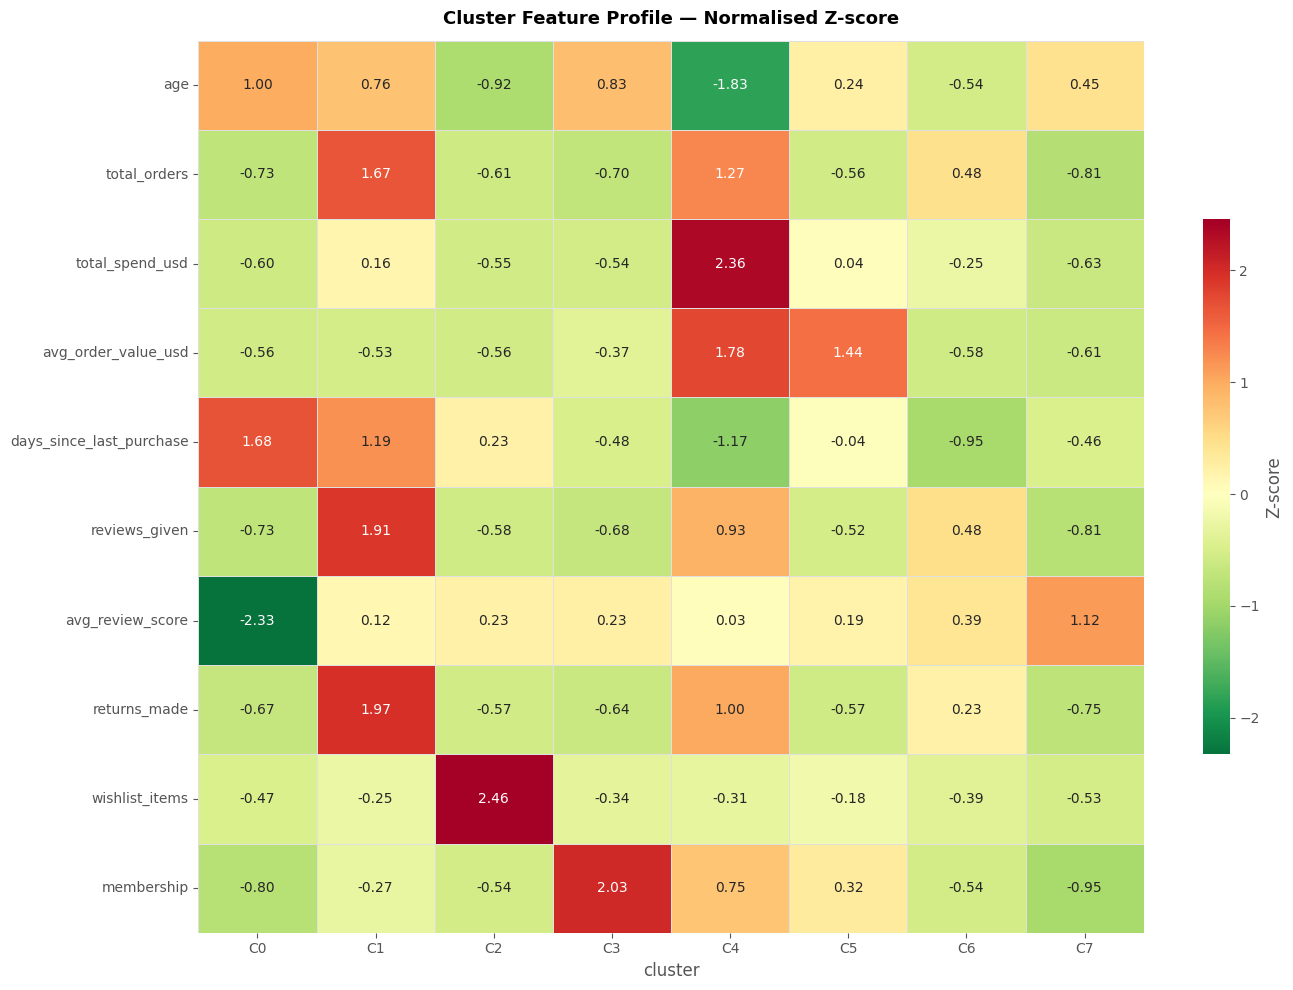

In [28]:

profile = df_numeric.groupby("cluster")[numeric_cols].mean()
profile_norm = (profile - profile.mean()) / profile.std()

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    profile_norm.T,
    ax=ax,
    cmap="RdYlGn_r",
    center=0,
    linewidths=0.4,
    linecolor="#e0e0e0",
    annot=True,
    fmt = '.2f',
    cbar_kws={"shrink": 0.6, "label": "Z-score"},
    xticklabels=[f"C{i}" for i in range(len(profile_norm))],
    yticklabels=numeric_cols,
)
ax.set_title("Cluster Feature Profile — Normalised Z-score", fontsize=13, fontweight="bold", pad=12)
plt.setp(ax.get_xticklabels(), rotation=0)
plt.setp(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

    While the elbow/silhouette method suggests `k = 10` as optimal, `k = 8` provides a more interpretable solution. 
---
**Cluster 0 — Dissatisfied Casuals**
- This is the lowest-engagement segment 
- Customers here have modest order counts (~10), low average spend, and — critically — the lowest review score in the dataset at 3.41 
- near-zero membership tier, these users likely have no strong brand loyalty.

    *Insight:* They buy occasionally but leave **dissatisfied**, making this a priority segment for win-back and satisfaction improvement campaigns.
---
**Cluster 1 — High-Volume Buyers (return-prone)**
- The most active buyers by order count (~52 orders)
- $4,018 in total spend and the **highest number** of reviews given (12.6) 
- Membership sits mid-range (~0.74), indicating many are free-tier despite high activity. A tiered upgrade nudge could be highly effective here.

    *Insight:* Their satisfaction score is solid at 4.12, but they also generate the most returns (4.5 on average) — suggesting either **impulse-buying** behavior or **poor product-expectation**. Better product description / showing return policy to discouraged such action, or lean into the impuslving and flash sales
---
**Cluster 2 — Wishlist Hoarders**
- Unusually high wishlist count (~15.3 items), far above any other cluster. 
- These customers browse and save, but don't commit — order counts and spend remain modest. 
- Review scores are high (4.15), suggesting they are satisfied when they do buy; the barrier is likely price sensitivity or timing. 

    *Insight:* Flash sales, wishlist-triggered discount alerts, or "limited stock" nudges would target this group directly.
---
**Cluster 3 — Platinum Inactives**
- highest membership score by a wide margin (2.39), which in context suggests gold or platinum tier customers. 
- Order counts (~10.7) and total spend (~$1,009) are relatively low
  
    *Insight:* they hold premium membership but don't transact at a commensurate rate. They may be lapsed loyalists. Targeted re-engagement with exclusive perks or personalized offers could reactivate this segment.
---
**Cluster 4 — Luxury/Premium Buyers**
- The highest-value segment overall. 
- With a mean average order value of $322 and total spend of $13,490, these customers purchase high-ticket items at significant volume (~44.7 orders). 
- Membership is mid-tier (~1.47), somewhat surprising given their spend
  
    *Insight:* There may be room to migrate them into a premium tier. Return rates (~3.0) are elevated but proportionate to order volume. 
---
**Cluster 5 — Occasional but considered Big Spenders**
- Cluster 4 in average order value (~$287), but with far fewer orders (~13.2), giving a total spend of ~$3,515. 
- Return way less (0.50)
- Buy infrequently but choose expensive items when they do. 
  *Insight:* This is a classic "high-value, low-frequency" profile. Strategies that increase purchase frequency — `seasonal campaigns, back-in-stock notifications, curated recommendations` — could significantly lift their lifetime value.
---
**Cluster 6 — Mid-Tier Regular Buyers** 
- With ~31 orders and $2,260 in total spend at a low average order value (~$75), these customers purchase steadily but stick to lower-priced items. 
- Review participation is decent (6.6 reviews), suggesting reasonable engagement. They represent the reliable middle — not flashy, but consistent. 
- Upselling to higher-margin categories could increase their contribution without heavy acquisition costs.
  
    *Insight:* A well-rounded, moderate group. But always present and buy at a constant pace
---
**Cluster 7 — Satisfied Inactives**
- The lowest order count (~8.8) but the highest review score in the dataset at 4.41, with the fewest returns (0.22). 
- These customers buy rarely, but when they do, they're happy. 
- Low membership score suggests they're not highly invested in the brand, yet their satisfaction is high. 
    *Insight:* This is a sleeper group — low effort to keep happy, but undermonetized. Gentle engagement (loyalty nudges, "we miss you" campaigns) could convert satisfaction into more frequent purchases.
---
## **Summary observations across clusters:**

- Age is nearly uniform across all clusters (~34–36), so it is not a differentiating feature — the segmentation is driven entirely by behavioral and transactional signals.
- Recency (days since last purchase, ~54–67 days) is also relatively flat, which is worth noting if churn analysis is a follow-up objective.
- The two highest-ROI segments are likely Cluster 4 (protect and delight) and Cluster 2 (convert wishlist intent into purchases).

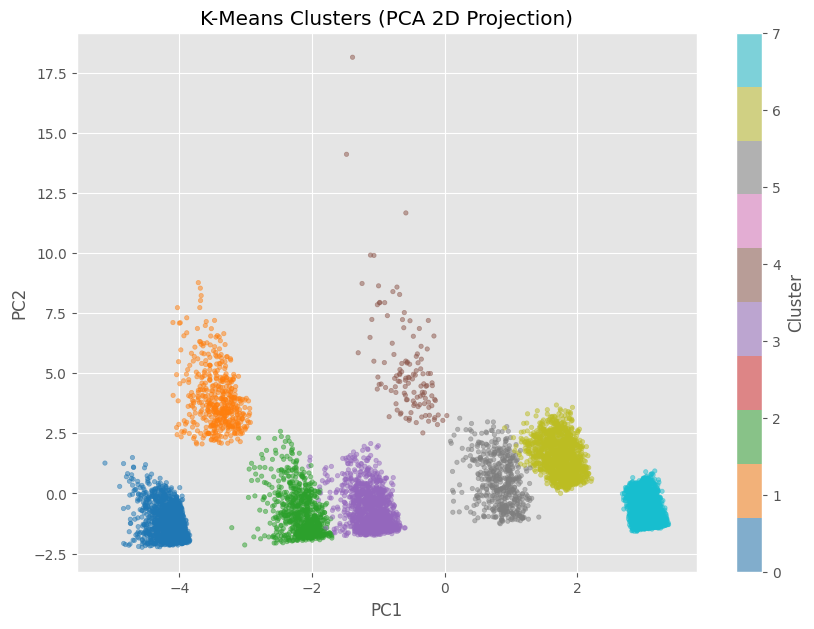

In [29]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(df_numeric)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(components[:, 0], components[:, 1], 
                      c=df['cluster'], cmap='tab10', alpha=0.5, s=10)
plt.colorbar(scatter, label='Cluster')
plt.title('K-Means Clusters (PCA 2D Projection)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


In [30]:
label_map = {
    0: 'Dissatisfied Casuals',
    1: 'High-Volume Buyers',
    2: 'Wishlist Hoarders',
    3: 'Platinum Inactives',
    4: 'Luxury Buyers',
    5: 'Occasional Big Spenders',
    6: 'Mid-Tier Regulars',
    7: 'Satisfied Inactives'
}

df['cluster_label'] = df['cluster'].map(label_map)


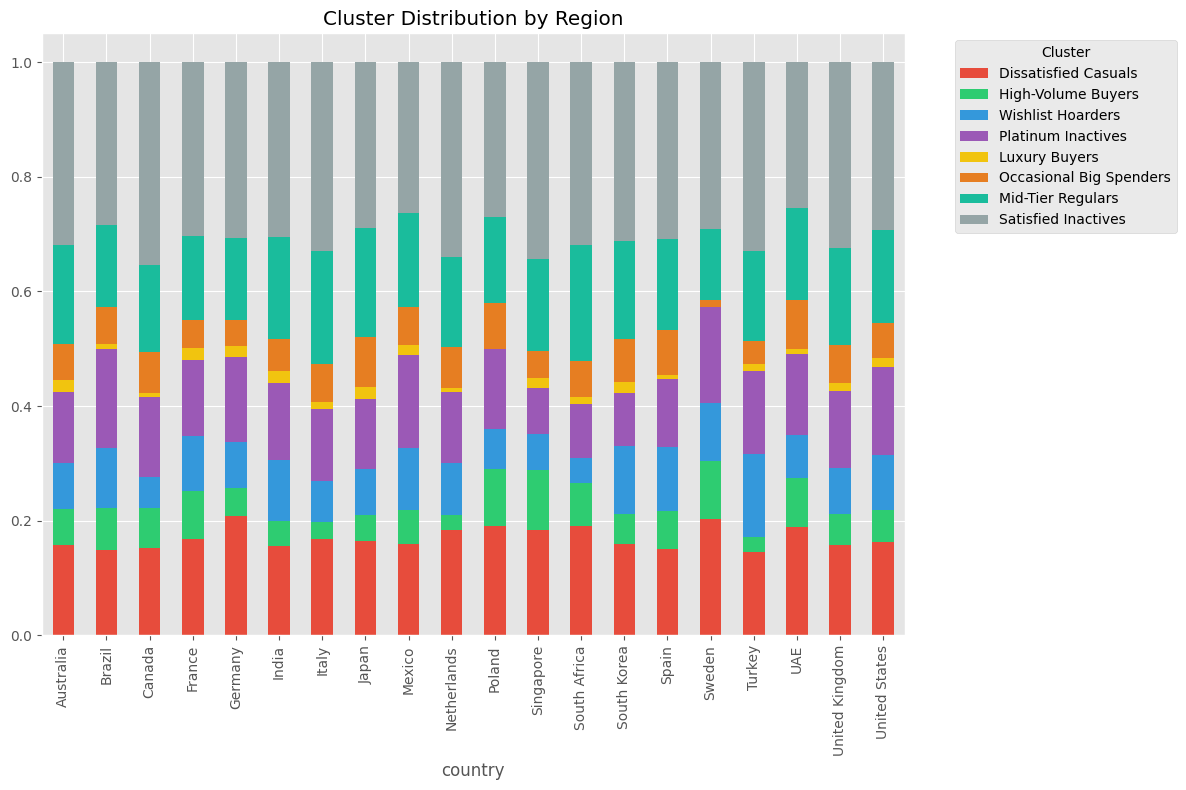

In [31]:
cluster_colors = {
    0: '#e74c3c',  
    1: '#2ecc71',  
    2: '#3498db',  
    3: '#9b59b6',   
    4: '#f1c40f',  
    5: '#e67e22', 
    6: '#1abc9c',  
    7: '#95a5a6',  
}

ax = pd.crosstab(df['country'], df['cluster'], normalize='index').plot(
    kind='bar', stacked=True,
    color=[cluster_colors[i] for i in range(8)],
    figsize=(12, 8)
)
plt.title('Cluster Distribution by Region')
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, [label_map[i] for i in range(8)], title='Cluster', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()



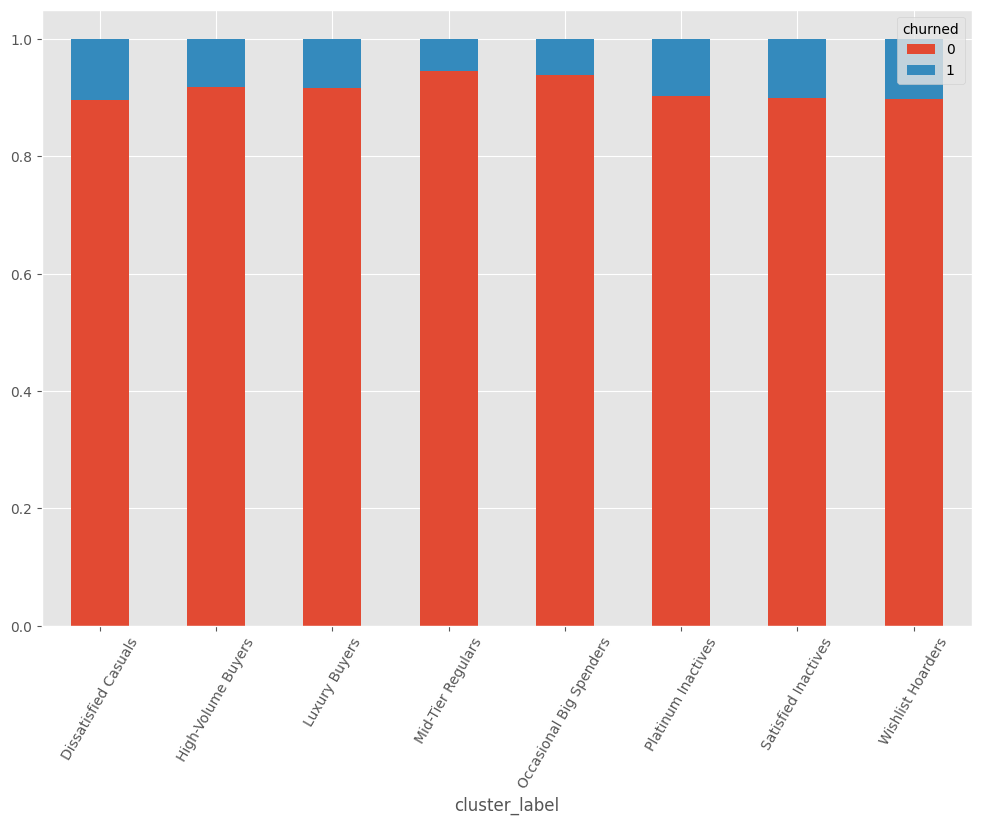

In [32]:
pd.crosstab(df['cluster_label'], df['churned'], normalize= 'index').plot(
    kind = 'bar', stacked= True,
    figsize= (12, 8)
)

plt.xticks(rotation = 60)
plt.show()

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   country                   8000 non-null   str           
 1   age                       8000 non-null   int64         
 2   gender                    8000 non-null   str           
 3   membership_tier           8000 non-null   str           
 4   registration_date         8000 non-null   datetime64[us]
 5   total_orders              8000 non-null   int64         
 6   total_spend_usd           8000 non-null   float64       
 7   avg_order_value_usd       8000 non-null   float64       
 8   days_since_last_purchase  8000 non-null   int64         
 9   preferred_category        8000 non-null   str           
 10  preferred_device          8000 non-null   str           
 11  preferred_payment_method  8000 non-null   str           
 12  acquisition_channel       8000 

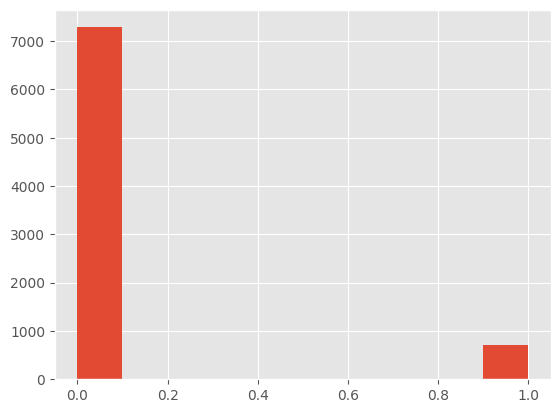

churned
0    0.910625
1    0.089375
Name: proportion, dtype: float64


In [34]:
df['churned'].hist()
plt.show()
print(df['churned'].value_counts(normalize=True))

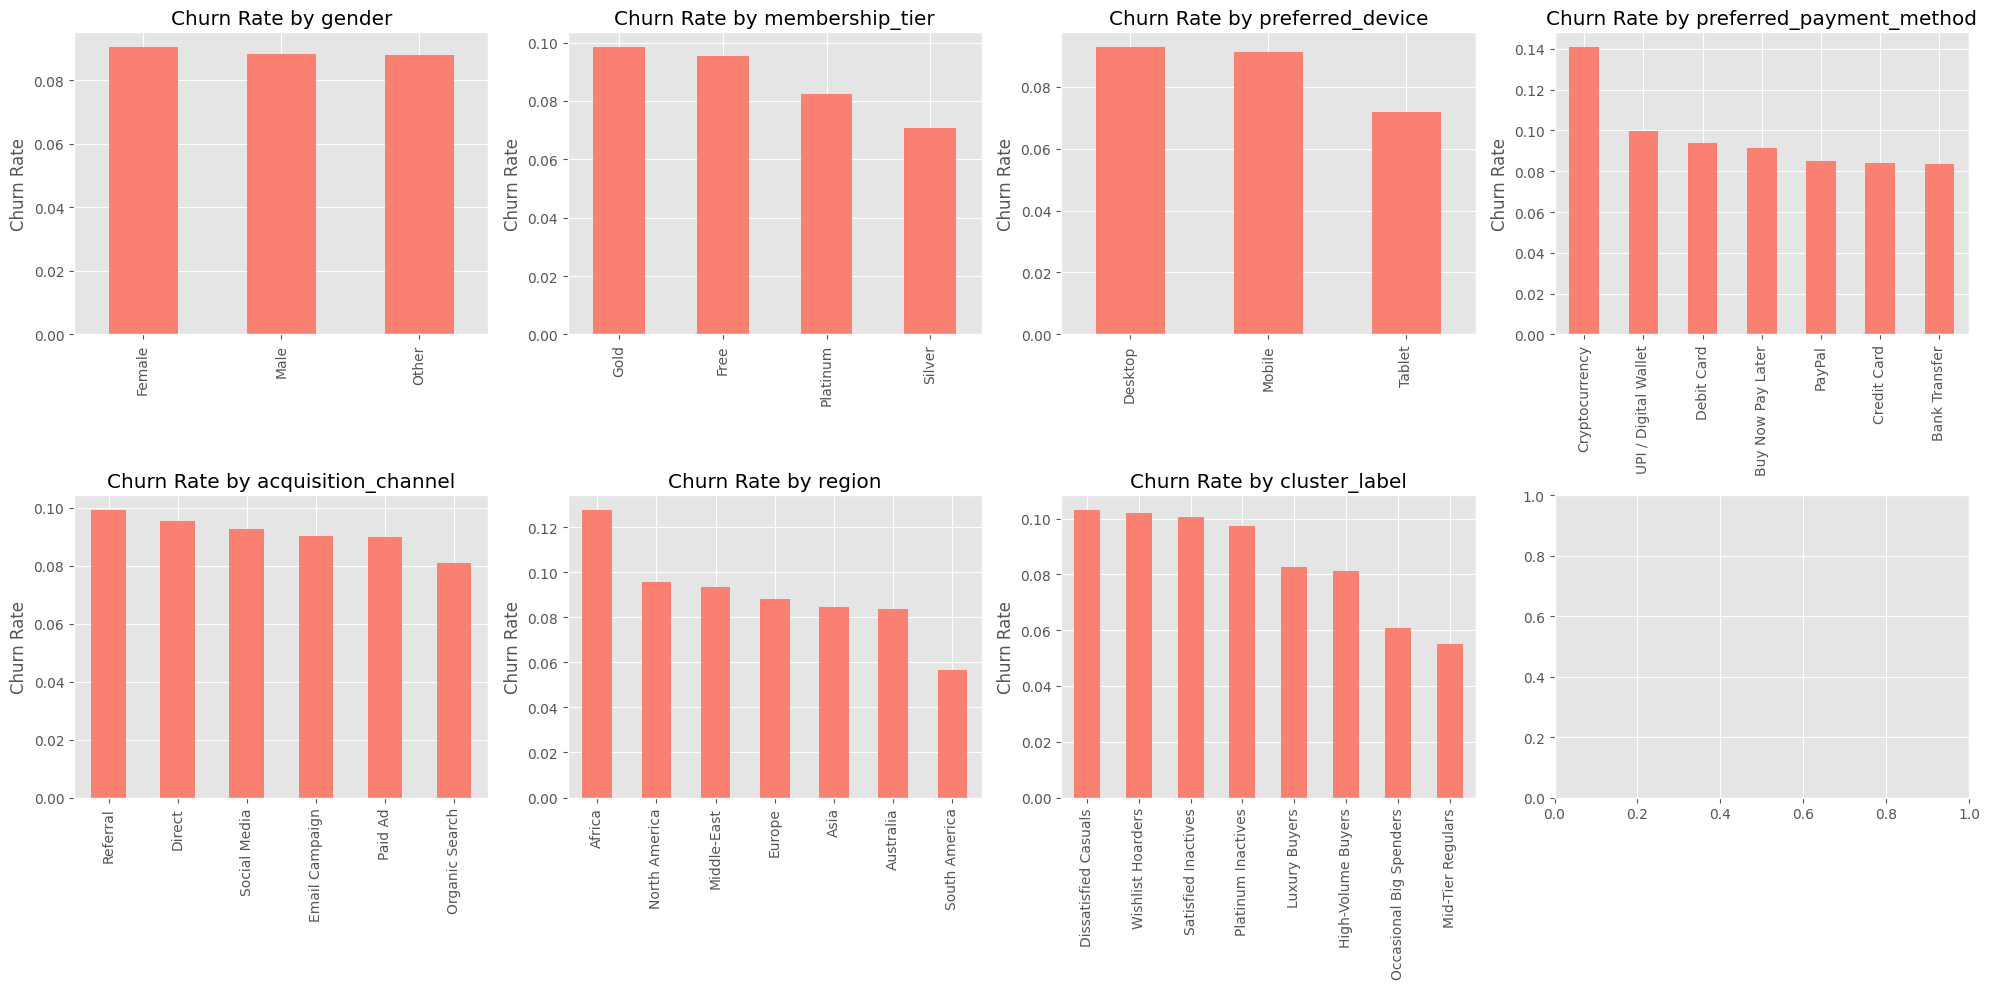

In [35]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

cat_feature = ['gender', 'membership_tier', 'preferred_device', 'preferred_payment_method',
               'acquisition_channel', 'region', 'cluster_label'
               ]

for ax, feat in zip(axes.flatten(), cat_feature):
    churn_rate = df.groupby(feat)['churned'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=ax, color='salmon')
    ax.set_title(f'Churn Rate by {feat}')
    ax.set_ylabel('Churn Rate')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


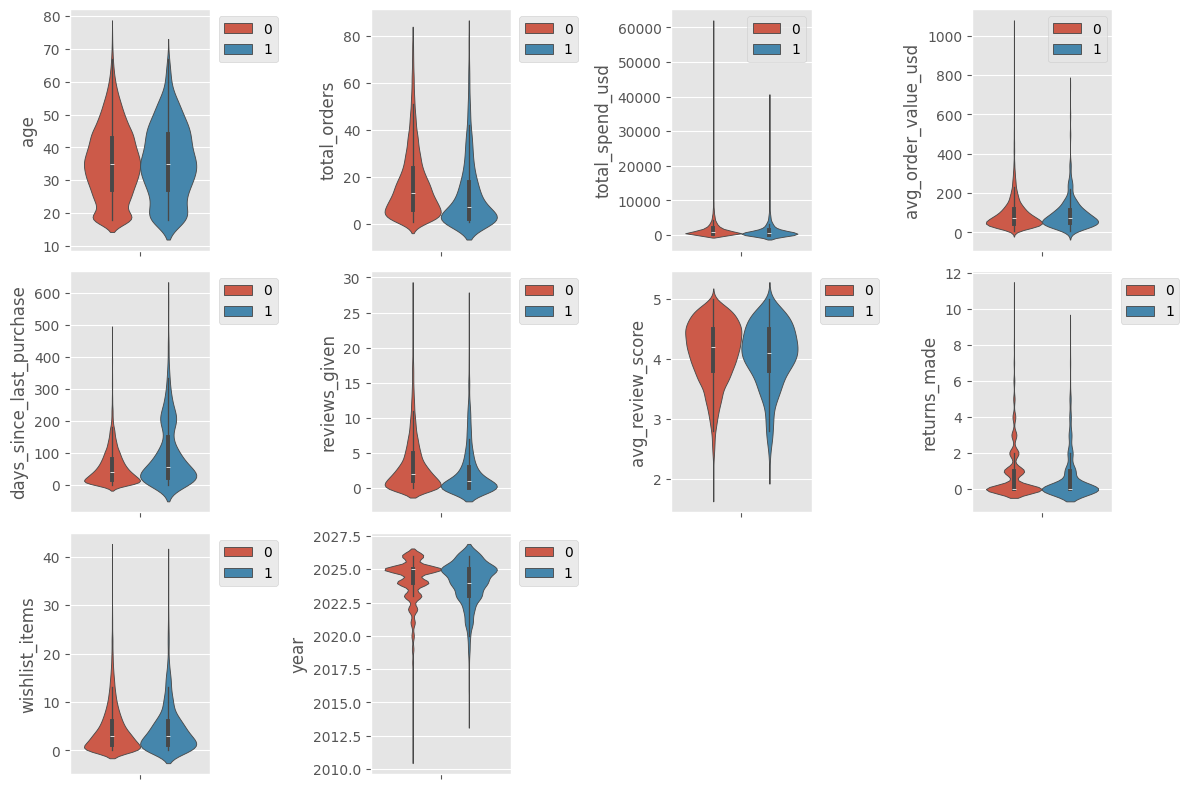

In [36]:
num_category = ['age', 'total_orders', 'total_spend_usd', 'avg_order_value_usd',
                'days_since_last_purchase', 'reviews_given', 'avg_review_score','returns_made', 
                'wishlist_items', 'year'
                ]

plt.figure(figsize = (12, 8))

for count, feat in enumerate(num_category):
    plt.subplot(3, 4, count + 1)
    sns.violinplot(df, hue = 'churned', y = feat )
    # df.groupby(feat)['churned'].mean().sort(ascending = False).plot(kind = 'bar')
    plt.legend(bbox_to_anchor= [1.01, 1])


plt.tight_layout()
plt.show()




In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   country                   8000 non-null   str           
 1   age                       8000 non-null   int64         
 2   gender                    8000 non-null   str           
 3   membership_tier           8000 non-null   str           
 4   registration_date         8000 non-null   datetime64[us]
 5   total_orders              8000 non-null   int64         
 6   total_spend_usd           8000 non-null   float64       
 7   avg_order_value_usd       8000 non-null   float64       
 8   days_since_last_purchase  8000 non-null   int64         
 9   preferred_category        8000 non-null   str           
 10  preferred_device          8000 non-null   str           
 11  preferred_payment_method  8000 non-null   str           
 12  acquisition_channel       8000 

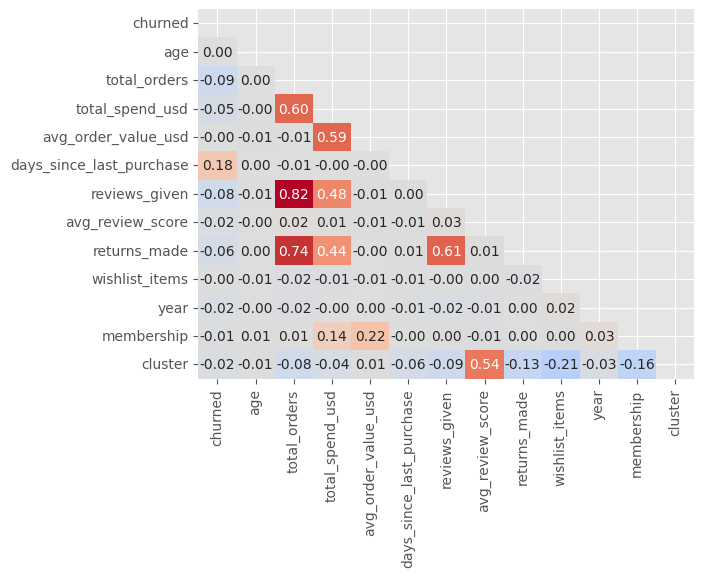

In [38]:
import numpy as np

corr_feat = num_category + ['membership', 'cluster']
target = ['churned']
matrix = df[target + corr_feat].corr()

mask = np.triu(np.ones_like(matrix, dtype = bool))

sns.heatmap(matrix, mask= mask, fmt = '.2f', cmap = 'coolwarm',
            center = 0, annot = True, cbar= False)
plt.show()

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   country                   8000 non-null   str           
 1   age                       8000 non-null   int64         
 2   gender                    8000 non-null   str           
 3   membership_tier           8000 non-null   str           
 4   registration_date         8000 non-null   datetime64[us]
 5   total_orders              8000 non-null   int64         
 6   total_spend_usd           8000 non-null   float64       
 7   avg_order_value_usd       8000 non-null   float64       
 8   days_since_last_purchase  8000 non-null   int64         
 9   preferred_category        8000 non-null   str           
 10  preferred_device          8000 non-null   str           
 11  preferred_payment_method  8000 non-null   str           
 12  acquisition_channel       8000 

In [40]:
target = 'churned'
cat_feat = [
    'gender', 'region', 'preferred_category', 'preferred_device',
    'preferred_payment_method', 'acquisition_channel', 'cluster_label'
]

num_feat = [
    # 'age', 
    'total_orders', 'total_spend_usd', 'days_since_last_purchase',
    'reviews_given', 
    'avg_review_score', 
    # 'returns_made', 
    'wishlist_items',
    'membership', 
    # 'year'
]

bin_feat = [
    'newsletter_subscribed'
]

In [41]:
from sklearn.model_selection import train_test_split

X = df[cat_feat + num_feat + bin_feat].copy()
y = df[target].copy()

X_train, X_temp, y_train, y_temp = train_test_split(X, y, random_state= 8,
                                                    test_size= 0.3, stratify= y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, random_state= 8,
                                                    test_size= 0.5, stratify= y_temp)

print(X_train.shape, X_val.shape, X_test.shape)



(5600, 15) (1200, 15) (1200, 15)


In [42]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.base import clone
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()

preprocessing = ColumnTransformer([
    ('num', StandardScaler(), num_feat),
    ('cat', OneHotEncoder(handle_unknown= 'ignore'), cat_feat),
    ('bin', 'passthrough', bin_feat)
])


models = {
    'xgb' : Pipeline([
        ('prep', clone(preprocessing)),
        # ('smote', SMOTE(sampling_strategy= 'minority', random_state= 8)),
        ('model', XGBClassifier(
            n_estimators = 300,
            random_state = 8,
            scale_pos_weight = pos_ratio,
            max_depth = 2,
            eval_metric = 'aucpr'
        ))]),
    'log_reg': Pipeline([
        ('prep', clone(preprocessing)),
        ('smote', SMOTE(sampling_strategy= 'minority', random_state= 8)),
        ('model', LogisticRegression(
            max_iter= 500,
            # class_weight = 'balanced',
            
        ))
    ])
    
}

In [43]:
val_pred = {}

for name, model in models.items():
    print(f'Training {name}')
    model.fit(X_train, y_train)
    print(f'Validating {name}')
    val_pred[name] = model.predict(X_val)

Training xgb
Validating xgb
Training log_reg
Validating log_reg


Classification report for xgb model:
              precision    recall  f1-score   support

           0       0.94      0.83      0.88      1093
           1       0.22      0.49      0.30       107

    accuracy                           0.80      1200
   macro avg       0.58      0.66      0.59      1200
weighted avg       0.88      0.80      0.83      1200

Classification report for log_reg model:
              precision    recall  f1-score   support

           0       0.94      0.64      0.76      1093
           1       0.14      0.60      0.23       107

    accuracy                           0.64      1200
   macro avg       0.54      0.62      0.50      1200
weighted avg       0.87      0.64      0.72      1200



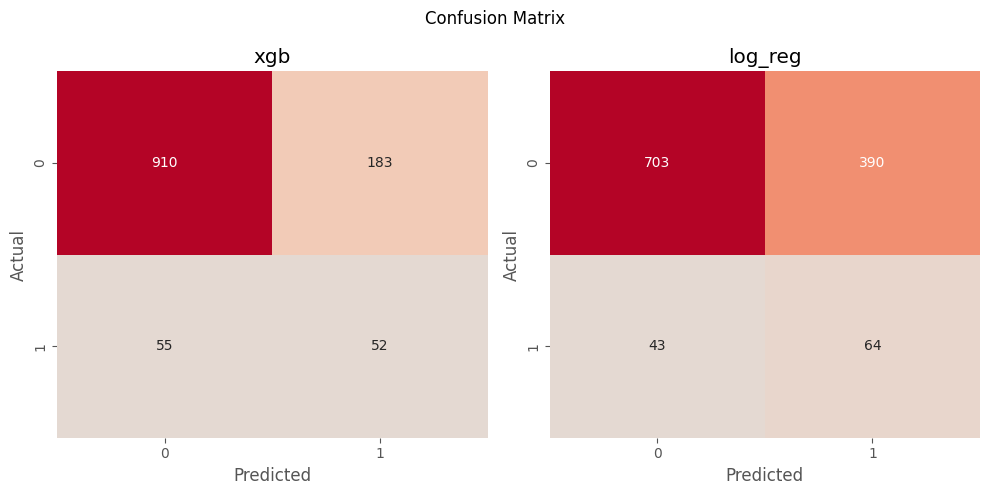

In [44]:
from sklearn.metrics import confusion_matrix, classification_report

plt.figure(figsize=(10, 5))
for count, (name, y_pred) in enumerate(val_pred.items()):
    print(f"Classification report for {name} model:")
    print(classification_report(y_val, y_pred))
    print("==" * 20)

    plt.subplot(1, 2, count + 1)
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, cmap = 'coolwarm', cbar = False, center = 0,
                annot = True, fmt = 'd')
    plt.title(f'{name}')
    plt.suptitle('Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')

plt.tight_layout()
plt.show()



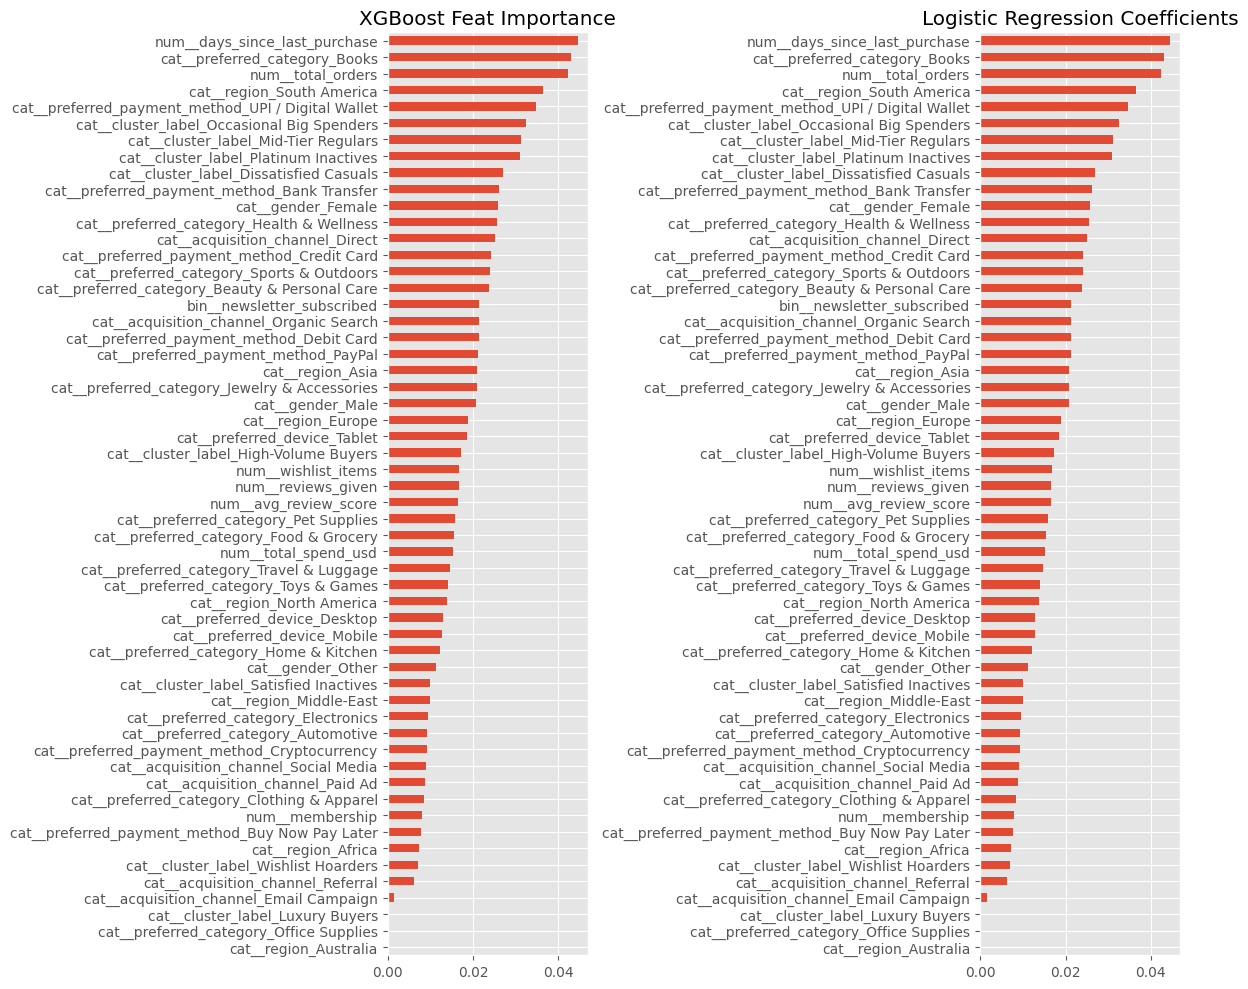

In [45]:
plt.figure(figsize=(12, 10))

plt.subplot(1, 2, 1)
xgb_model = models['xgb']
feature_names = xgb_model.named_steps['prep'].get_feature_names_out()
importances = xgb_model.named_steps['model'].feature_importances_

pd.Series(importances, index = feature_names).sort_values().plot(kind = 'barh')
plt.title('XGBoost Feat Importance')

plt.subplot(1, 2, 2)
log_model = models['log_reg']
feature_names = log_model.named_steps['prep'].get_feature_names_out()
coefs = log_model.named_steps['model'].coef_[0]

pd.Series(importances, index = feature_names).sort_values().plot(kind = 'barh')
plt.title('Logistic Regression Coefficients')


plt.tight_layout()
plt.show()






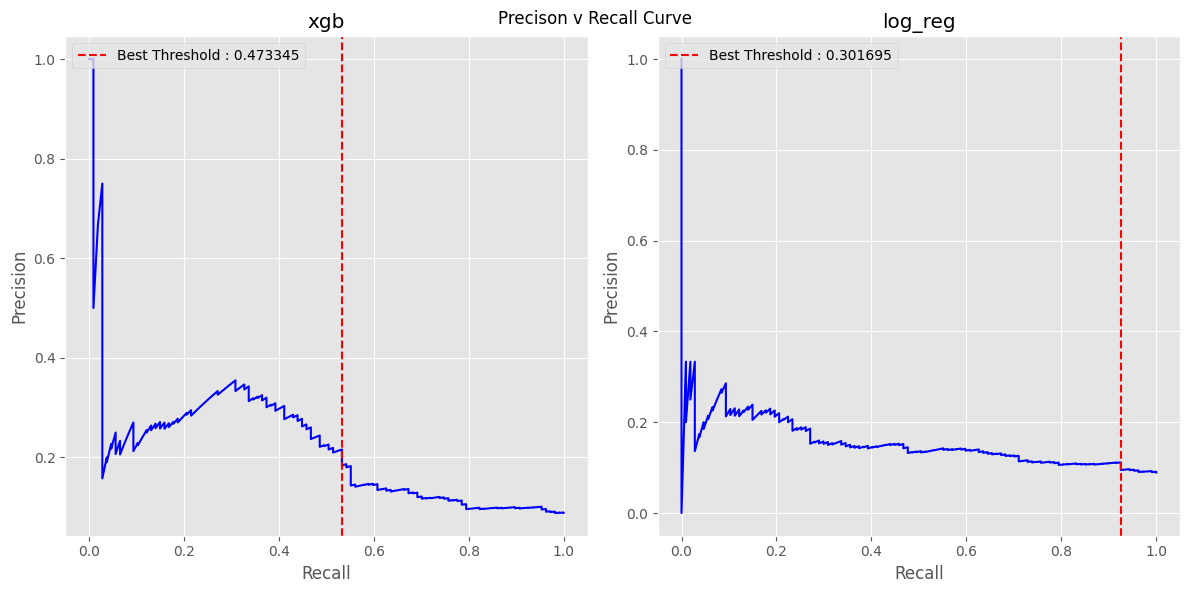

In [46]:
from sklearn.metrics import precision_recall_curve, fbeta_score

best_threshold = {}
y_proba = {}

plt.figure(figsize= (12, 6))

for count, (name, model) in enumerate(models.items()):
    y_proba = model.predict_proba(X_val)[:, 1]
    precisions, recall, thresholds = precision_recall_curve(y_val, y_proba)

    f2_scores = [fbeta_score(y_val, (y_proba >= t).astype(int), beta = 2) for t in thresholds]
    best_t = thresholds[np.argmax(f2_scores)]
    best_threshold[name] = best_t

    plt.subplot(1, 2, count + 1)
    plt.plot(recall, precisions, color = 'blue')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.axvline(recall[np.argmax(f2_scores)], color = 'red', linestyle = '--', label = f'Best Threshold :{best_t: 2f}')
    plt.title(f'{name}')
    plt.legend(loc = 'upper left')


plt.tight_layout()
plt.suptitle('Precison v Recall Curve')
plt.show()


Classification report for xgb model:
              precision    recall  f1-score   support

           0       0.91      0.79      0.85      1093
           1       0.08      0.18      0.11       107

    accuracy                           0.74      1200
   macro avg       0.49      0.49      0.48      1200
weighted avg       0.83      0.74      0.78      1200

Classification report for log_reg model:
              precision    recall  f1-score   support

           0       0.91      0.62      0.74      1093
           1       0.09      0.38      0.15       107

    accuracy                           0.60      1200
   macro avg       0.50      0.50      0.44      1200
weighted avg       0.84      0.60      0.69      1200



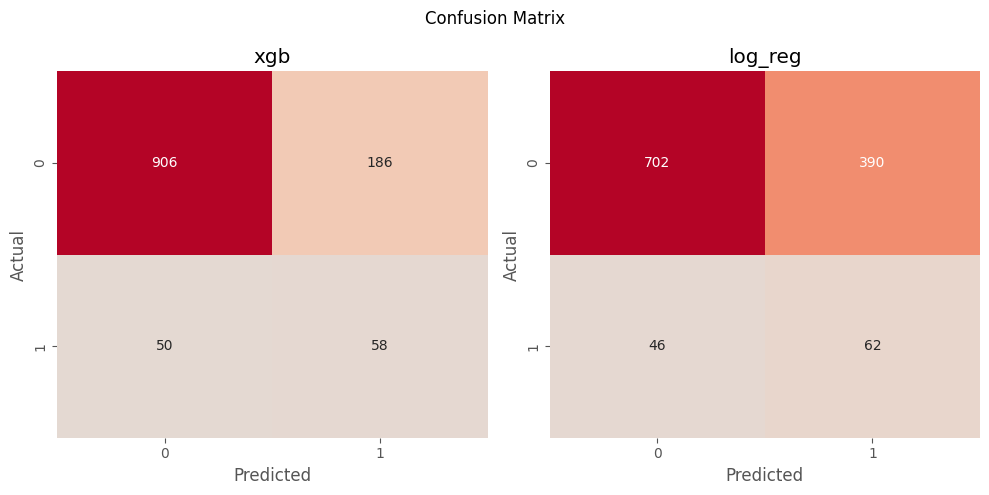

In [47]:
plt.figure(figsize=(10, 5))
for count, (name, model) in enumerate(models.items()):

    y_pred = model.predict(X_test)

    print(f"Classification report for {name} model:")
    print(classification_report(y_val, y_pred))
    print("==" * 20)

    plt.subplot(1, 2, count + 1)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, cmap = 'coolwarm', cbar = False, center = 0,
                annot = True, fmt = 'd')
    plt.title(f'{name}')
    plt.suptitle('Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')

plt.tight_layout()
plt.show()



Classification report for xgb model:
              precision    recall  f1-score   support

           0       0.91      0.77      0.83      1093
           1       0.08      0.20      0.11       107

    accuracy                           0.72      1200
   macro avg       0.49      0.48      0.47      1200
weighted avg       0.83      0.72      0.77      1200

Classification report for log_reg model:
              precision    recall  f1-score   support

           0       0.93      0.27      0.42      1093
           1       0.10      0.80      0.17       107

    accuracy                           0.32      1200
   macro avg       0.52      0.54      0.30      1200
weighted avg       0.86      0.32      0.40      1200



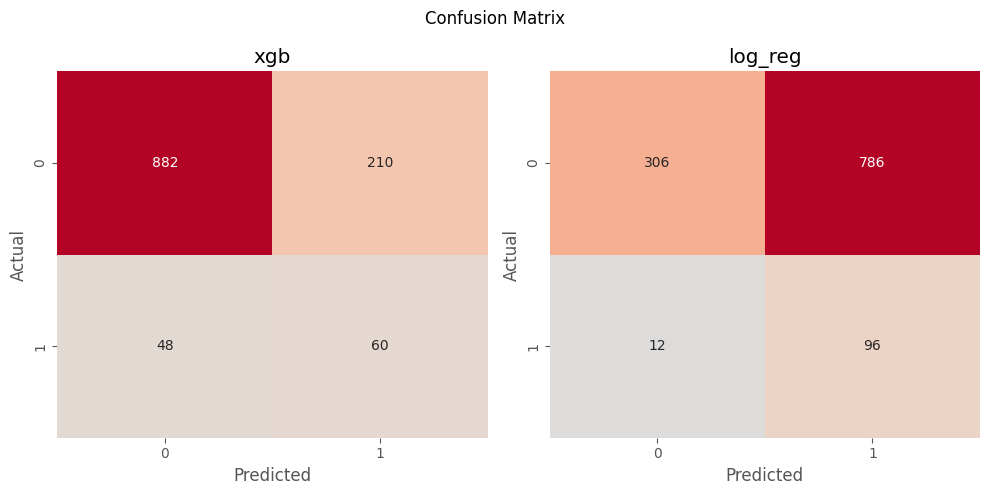

In [48]:
plt.figure(figsize=(10, 5))
for count, (name, model) in enumerate(models.items()):

    y_prob = model.predict_proba(X_test)[:, 1]

    y_pred = (y_prob >= best_threshold[name]).astype(int)

    print(f"Classification report for {name} model:")
    print(classification_report(y_val, y_pred))
    print("==" * 20)

    plt.subplot(1, 2, count + 1)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, cmap = 'coolwarm', cbar = False, center = 0,
                annot = True, fmt = 'd')
    plt.title(f'{name}')
    plt.suptitle('Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')

plt.tight_layout()
plt.show()



## Churn Classification

### Approach
[What models did you use, how did you handle class imbalance, and why]

We use `XGboost` and `LogReg` to classify the **churned** value of customer, we have a hight imbalance issue with the **churned** value, we use postiive ratio (pos_ratio) for `XGBoost` and *SMOTE* for the `LogReg`

We also use some threshold tuning for testing the peformance. We use the validation set to test, finetune and find the thresholds. And the use the test set for the final results

Our model was highly overffiting with our validation set, early stopping can be used to help mitigate this

